In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/Order_details1.csv",encoding="latin-1")
Customer=pd.read_csv("/content/Cust.csv")

In [ ]:
df[df['Customer_ID']=='0']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer_ID,Country
622,536414,22139,NaN,56.0,12-01-2010 11:52,0.00,0,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1.0,12-01-2010 14:32,2.51,0,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2.0,12-01-2010 14:32,2.51,0,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4.0,12-01-2010 14:32,0.85,0,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2.0,12-01-2010 14:32,1.66,0,United Kingdom
...,...,...,...,...,...,...,...,...
11542,537253,22493,PAINT YOUR OWN CANVAS SET,4.0,12-06-2010 10:53,1.65,0,United Kingdom
11543,537253,21891,TRADITIONAL WOODEN SKIPPING ROPE,2.0,12-06-2010 10:53,1.25,0,United Kingdom
11544,537253,21890,S/6 WOODEN SKITTLES IN COTTON BAG,2.0,12-06-2010 10:53,2.95,0,United Kingdom
11545,537253,22620,4 TRADITIONAL SPINNING TOPS,8.0,12-06-2010 10:53,1.25,0,United Kingdom


In [ ]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer_ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12-01-2010 08:26,2.55,AH-17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12-01-2010 08:26,3.39,AH-17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12-01-2010 08:26,2.75,AH-17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12-01-2010 08:26,3.39,AH-17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12-01-2010 08:26,3.39,AH-17850,United Kingdom
...,...,...,...,...,...,...,...,...
11963,537354,21033,JUMBO BAG CHARLIE AND LOLA TOYS,2.0,12-06-2010 12:23,2.95,EC-12748,United Kingdom
11964,537354,22356,CHARLOTTE BAG PINK POLKADOT,2.0,12-06-2010 12:23,0.85,EC-12748,United Kingdom
11965,537354,20724,RED RETROSPOT CHARLOTTE BAG,5.0,12-06-2010 12:23,0.85,EC-12748,United Kingdom
11966,537354,22382,LUNCH BAG SPACEBOY DESIGN,2.0,12-06-2010 12:23,1.65,EC-12748,United Kingdom


In [ ]:
df.shape

(11968, 8)

In [ ]:
Customer

,Customer_ID,Customer_Name
0,AH-17850,Allison Hill
1,NR-13047,Noah Rhodes
2,AH-12583,Angie Henderson
3,DW-13748,Daniel Wagner
4,CS-15100,Cristian Santos
...,...,...
4368,HL-13436,Harold Lee
4369,CG-15520,Carol Gay
4370,MN-13298,Michael Nelson
4371,DM-14569,Daniel Meyer


# Data Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11968 entries, 0 to 11967
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    11968 non-null  object 
 1   StockCode    11967 non-null  object 
 2   Description  11925 non-null  object 
 3   Quantity     11967 non-null  float64
 4   InvoiceDate  11967 non-null  object 
 5   UnitPrice    11967 non-null  float64
 6   Customer_ID  11967 non-null  object 
 7   Country      11967 non-null  object 
dtypes: float64(2), object(6)
memory usage: 748.1+ KB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,1
Description,43
Quantity,1
InvoiceDate,1
UnitPrice,1
Customer_ID,1
Country,1


In [ ]:
df=df.dropna(subset=['Customer_ID'])

In [ ]:
df.shape

(11967, 8)

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,42
Quantity,0
InvoiceDate,0
UnitPrice,0
Customer_ID,0
Country,0


In [ ]:
df['InvoiceNo'].nunique()

562

In [ ]:
df[df['InvoiceNo'].astype(str).str.startswith('C')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer_ID,Country
141,C536379,D,Discount,-1.0,12-01-2010 09:41,27.50,RM-14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1.0,12-01-2010 09:49,4.65,GD-15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12.0,12-01-2010 10:24,1.65,DZ-17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24.0,12-01-2010 10:24,0.29,DZ-17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24.0,12-01-2010 10:24,0.29,DZ-17548,United Kingdom


In [ ]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [ ]:
df[df['Quantity'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer_ID,Country
2406,536589,21777,NaN,-10.0,12-01-2010 16:50,0.0,0,United Kingdom
4347,536764,84952C,NaN,-38.0,12-02-2010 14:42,0.0,0,United Kingdom
7188,536996,22712,NaN,-20.0,12-03-2010 15:30,0.0,0,United Kingdom
7189,536997,22028,NaN,-20.0,12-03-2010 15:30,0.0,0,United Kingdom
7190,536998,85067,NaN,-6.0,12-03-2010 15:30,0.0,0,United Kingdom
7192,537000,21414,NaN,-22.0,12-03-2010 15:32,0.0,0,United Kingdom
7193,537001,21653,NaN,-6.0,12-03-2010 15:33,0.0,0,United Kingdom
7195,537003,85126,NaN,-2.0,12-03-2010 15:33,0.0,0,United Kingdom
7196,537004,21814,NaN,-30.0,12-03-2010 15:34,0.0,0,United Kingdom
7197,537005,21692,NaN,-70.0,12-03-2010 15:35,0.0,0,United Kingdom


In [ ]:
df[df['UnitPrice'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer_ID,Country
622,536414,22139,NaN,56.0,12-01-2010 11:52,0.0,0,United Kingdom
1970,536545,21134,NaN,1.0,12-01-2010 14:32,0.0,0,United Kingdom
1971,536546,22145,NaN,1.0,12-01-2010 14:33,0.0,0,United Kingdom
1972,536547,37509,NaN,1.0,12-01-2010 14:33,0.0,0,United Kingdom
1987,536549,85226A,NaN,1.0,12-01-2010 14:34,0.0,0,United Kingdom
1988,536550,85044,NaN,1.0,12-01-2010 14:34,0.0,0,United Kingdom
2024,536552,20950,NaN,1.0,12-01-2010 14:34,0.0,0,United Kingdom
2025,536553,37461,NaN,3.0,12-01-2010 14:35,0.0,0,United Kingdom
2026,536554,84670,NaN,23.0,12-01-2010 14:35,0.0,0,United Kingdom
2406,536589,21777,NaN,-10.0,12-01-2010 16:50,0.0,0,United Kingdom


In [ ]:
df=df[df['UnitPrice'] > 0]

In [ ]:
df.duplicated().sum()

np.int64(224)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Revenue']=(df['Quantity']*df['UnitPrice']).round(2)

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer_ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12-01-2010 08:26,2.55,AH-17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,12-01-2010 08:26,3.39,AH-17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12-01-2010 08:26,2.75,AH-17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12-01-2010 08:26,3.39,AH-17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12-01-2010 08:26,3.39,AH-17850,United Kingdom,20.34


In [ ]:
df['Description']=df['Description'].str.lower()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11572 entries, 0 to 11966
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    11572 non-null  object 
 1   StockCode    11572 non-null  object 
 2   Description  11572 non-null  object 
 3   Quantity     11572 non-null  float64
 4   InvoiceDate  11572 non-null  object 
 5   UnitPrice    11572 non-null  float64
 6   Customer_ID  11572 non-null  object 
 7   Country      11572 non-null  object 
 8   Revenue      11572 non-null  float64
dtypes: float64(3), object(6)
memory usage: 1.1+ MB


In [ ]:
df['InvoiceDate'].unique()

array(['12-01-2010 08:26', '12-01-2010 08:28', '12-01-2010 08:34',
       '12-01-2010 08:35', '12-01-2010 08:45', '12-01-2010 09:00',
       '12-01-2010 09:01', '12-01-2010 09:02', '12-01-2010 09:09',
       '12-01-2010 09:32', '12-01-2010 09:34', '12-01-2010 09:37',
       '12-01-2010 09:41', '12-01-2010 09:45', '12-01-2010 09:53',
       '12-01-2010 09:56', '12-01-2010 09:57', '12-01-2010 09:58',
       '12-01-2010 09:59', '12-01-2010 10:03', '12-01-2010 10:19',
       '12-01-2010 10:29', '12-01-2010 10:37', '12-01-2010 10:39',
       '12-01-2010 10:47', '12-01-2010 10:51', '12-01-2010 10:52',
       '12-01-2010 10:53', '12-01-2010 11:21', '12-01-2010 11:22',
       '12-01-2010 11:27', '12-01-2010 11:29', '12-01-2010 11:32',
       '12-01-2010 11:33', '12-01-2010 11:34', '12-01-2010 11:41',
       '12-01-2010 11:45', '12-01-2010 11:49', '12-01-2010 11:57',
       '12-01-2010 11:58', '12-01-2010 12:03', '12-01-2010 12:08',
       '12-01-2010 12:12', '12-01-2010 12:15', '12-01-2010 12:

In [ ]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    format='mixed',
    dayfirst=True
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11572 entries, 0 to 11966
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    11572 non-null  object        
 1   StockCode    11572 non-null  object        
 2   Description  11572 non-null  object        
 3   Quantity     11572 non-null  float64       
 4   InvoiceDate  11572 non-null  datetime64[ns]
 5   UnitPrice    11572 non-null  float64       
 6   Customer_ID  11572 non-null  object        
 7   Country      11572 non-null  object        
 8   Revenue      11572 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 1.1+ MB


In [ ]:
df['InvoiceDate']

,InvoiceDate
0,2010-01-12 08:26:00
1,2010-01-12 08:26:00
2,2010-01-12 08:26:00
3,2010-01-12 08:26:00
4,2010-01-12 08:26:00
...,...
11962,2010-06-12 12:23:00
11963,2010-06-12 12:23:00
11964,2010-06-12 12:23:00
11965,2010-06-12 12:23:00


In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'Customer_ID', 'Country', 'Revenue'],
      dtype='object')

In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,Revenue
count,11572.000000,11572,11572.000000,11572.000000
mean,8.777999,2010-03-20 02:18:02.006567680,4.069042,18.471497
min,1.000000,2010-01-12 08:26:00,0.100000,0.140000
25%,1.000000,2010-01-12 17:06:00,1.280000,3.360000
50%,2.000000,2010-03-12 11:36:00,2.510000,8.435000
75%,8.000000,2010-05-12 13:17:00,4.250000,17.000000
max,2880.000000,2010-06-12 12:23:00,940.870000,1627.200000
std,43.169679,NaN,17.872973,56.148107


In [ ]:
df.shape

(11572, 9)

In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'Customer_ID', 'Country', 'Revenue'],
      dtype='object')

In [ ]:
df['Customer_ID'].nunique()

335

# Feature Engineering

In [ ]:
# Get the maximum date from our entire data
df['InvoiceDate'].max()

Timestamp('2010-06-12 12:23:00')

In [ ]:
# RFM approach and avoids having many customers with Recency = 0 for that i add one day.
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2010-06-13 12:23:00')

In [ ]:
rfm = df.groupby('Customer_ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

In [ ]:
rfm

,InvoiceDate,InvoiceNo,Revenue
Customer_ID,,,
0,1,28,51418.20
AA-17819,92,1,591.47
AD-15574,120,1,349.04
AE-13370,93,1,754.87
AF-15955,121,1,572.38
...,...,...,...
WP-12472,31,1,1631.30
YB-15038,32,1,118.88
YC-17954,92,1,108.78


In [ ]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [ ]:
rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
0,1,28,51418.20
AA-17819,92,1,591.47
AD-15574,120,1,349.04
AE-13370,93,1,754.87
AF-15955,121,1,572.38


In [ ]:
rfm.shape

(335, 3)

In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,335.000000,335.000000,335.000000
mean,91.286567,1.397015,638.066149
std,52.826019,2.427510,2906.131430
min,1.000000,1.000000,15.000000
25%,32.000000,1.000000,183.900000
50%,120.000000,1.000000,299.400000
75%,121.000000,1.000000,428.600000
max,152.000000,34.000000,51418.200000


By analyzing, some customer are spend large, and some are spend low 25 percentile data has spend less than 711

In [ ]:
rfm=rfm.reset_index()

In [ ]:
rfm['Average_Order_Value'] = rfm['Monetary'] / rfm['Frequency']

In [ ]:
rfm.sort_values(by='Average_Order_Value',ascending=False)

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value
281,SD-16210,1,2,4738.54,2369.270000
16,AK-16754,120,1,2002.40,2002.400000
321,VG-12433,151,1,1919.14,1919.140000
0,0,1,28,51418.20,1836.364286
125,HW-17511,152,1,1825.74,1825.740000
...,...,...,...,...,...
245,NF-14865,120,1,37.20,37.200000
99,DS-14576,120,1,35.40,35.400000
19,AM-17460,120,2,70.30,35.150000
163,JR-17026,31,1,33.15,33.150000


In [ ]:
rfm['Customer_ID'].nunique()

335

In [ ]:
rfm.duplicated().sum()

np.int64(0)

In [ ]:
rfm.isna().sum()

,0
Customer_ID,0
Recency,0
Frequency,0
Monetary,0
Average_Order_Value,0


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary,Average_Order_Value
count,335.000000,335.000000,335.000000,335.000000
mean,91.286567,1.397015,638.066149,360.079796
std,52.826019,2.427510,2906.131430,352.267530
min,1.000000,1.000000,15.000000,15.000000
25%,32.000000,1.000000,183.900000,164.750000
50%,120.000000,1.000000,299.400000,273.290000
75%,121.000000,1.000000,428.600000,392.090000
max,152.000000,34.000000,51418.200000,2369.270000


In [ ]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335 entries, 0 to 334
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          335 non-null    object 
 1   Recency              335 non-null    int64  
 2   Frequency            335 non-null    int64  
 3   Monetary             335 non-null    float64
 4   Average_Order_Value  335 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
rfm=rfm[~(rfm['Customer_ID']=='0')]

In [ ]:
rfm

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value
1,AA-17819,92,1,591.47,591.47
2,AD-15574,120,1,349.04,349.04
3,AE-13370,93,1,754.87,754.87
4,AF-15955,121,1,572.38,572.38
5,AH-12583,152,1,855.86,855.86
...,...,...,...,...,...
330,WP-12472,31,1,1631.30,1631.30
331,YB-15038,32,1,118.88,118.88
332,YC-17954,92,1,108.78,108.78
333,ZF-16539,151,1,442.35,442.35


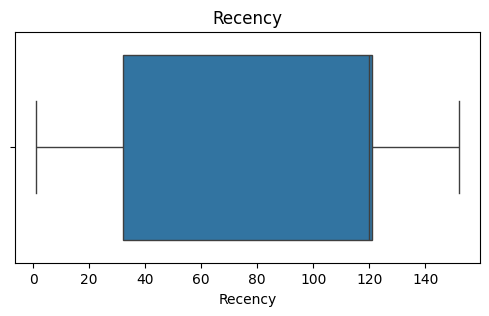

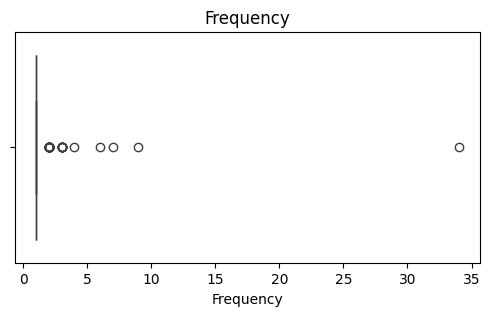

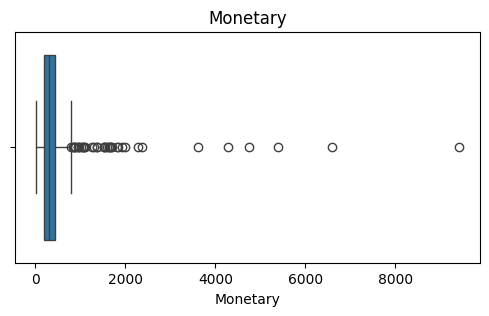

In [ ]:
# Checking outliers
for col in ['Recency', 'Frequency', 'Monetary']:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=rfm[col])
    plt.title(col)
    plt.show()

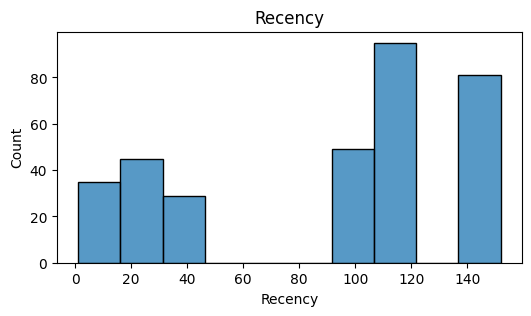

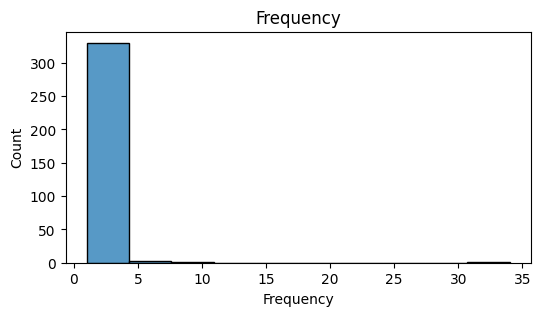

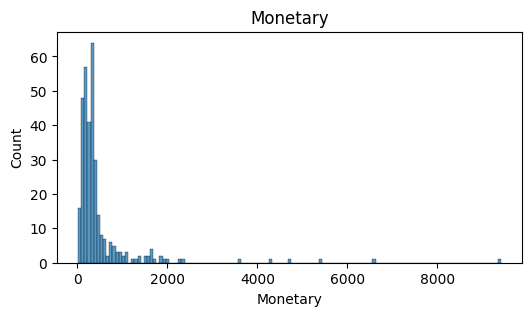

In [ ]:
for col in ['Recency', 'Frequency', 'Monetary']:
    plt.figure(figsize=(6,3))
    sns.histplot(x=rfm[col])
    plt.title(col)
    plt.show()

In [ ]:
# apply log transformation because they are right skewed
rfm_log = rfm.drop(columns=['Customer_ID','Average_Order_Value']).copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

In [ ]:
rfm_log

,Recency,Frequency,Monetary
1,4.532599,0.693147,6.384300
2,4.795791,0.693147,5.858047
3,4.543295,0.693147,6.627869
4,4.804021,0.693147,6.351549
5,5.030438,0.693147,6.753275
...,...,...,...
330,3.465736,0.693147,7.397745
331,3.496508,0.693147,4.786491
332,4.532599,0.693147,4.698478
333,5.023881,0.693147,6.094360


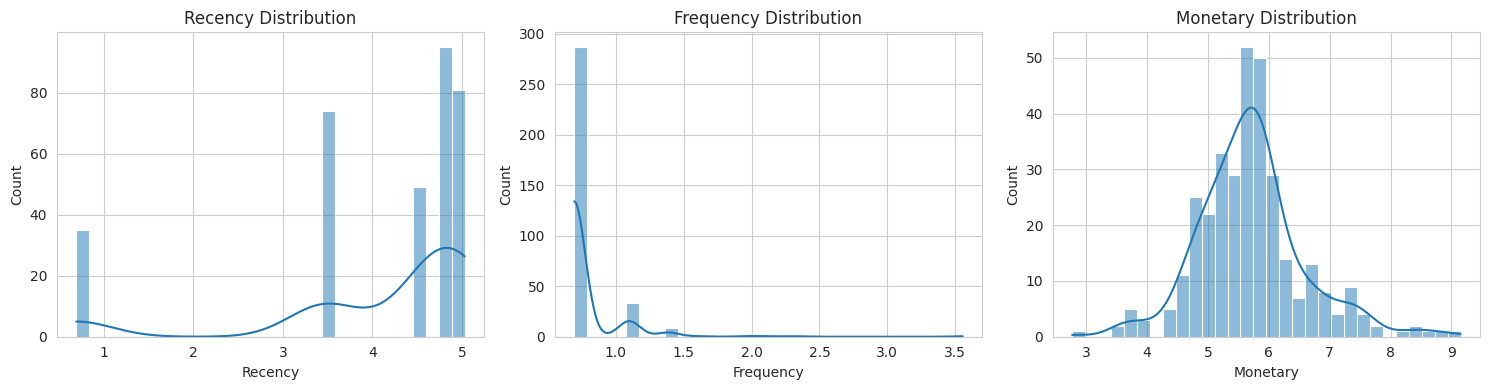

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Better style
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, len(rfm_log.columns), figsize=(15, 4))

for ax, col in zip(axes, rfm_log.columns):
    sns.histplot(
        data=rfm_log,
        x=col,
        kde=True,
        bins=30,
        ax=ax
    )
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

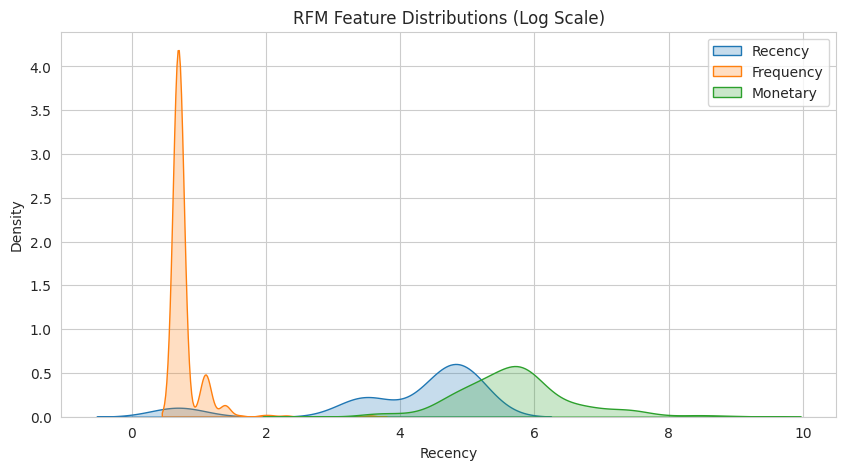

In [ ]:
plt.figure(figsize=(10, 5))

for col in rfm_log.columns:
    sns.kdeplot(rfm_log[col], label=col, fill=True)

plt.title('RFM Feature Distributions (Log Scale)')
plt.legend()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [ ]:
rfm.columns

Index(['Customer_ID', 'Recency', 'Frequency', 'Monetary',
       'Average_Order_Value'],
      dtype='object')

<Axes: >

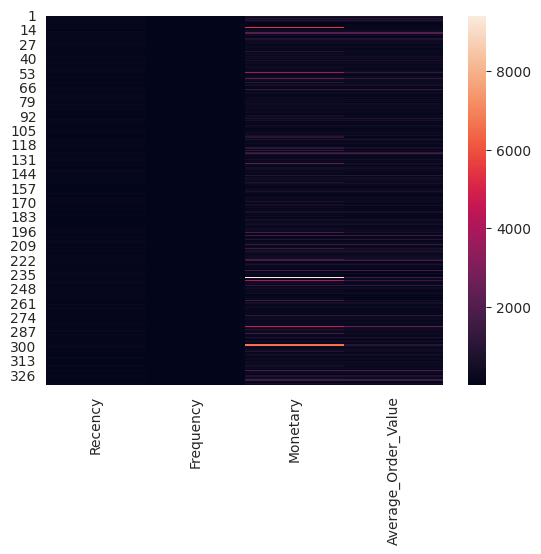

In [ ]:
sns.heatmap(rfm[['Recency', 'Frequency', 'Monetary',
       'Average_Order_Value']])

In [ ]:
rfm_scaled.shape

(334, 3)

# Machine Learning - Elbow Method used

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

In [ ]:
wcss

[1002.0000000000002,
 726.7570762957097,
 485.013242313285,
 367.62692222035616,
 284.24561120623486,
 245.83983974627822,
 202.33509833274937,
 164.49492449346778,
 144.84397459691795,
 124.05780507907033]

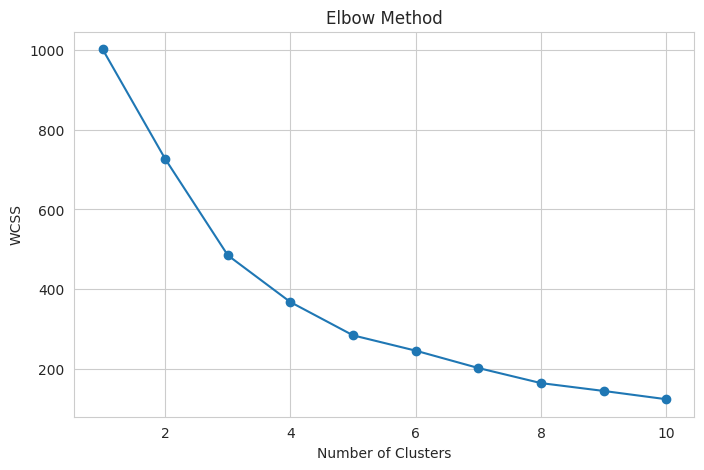

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)

    print(f'K={k}, Score={score:.3f}')

K=2, Score=0.566
K=3, Score=0.562
K=4, Score=0.383
K=5, Score=0.378
K=6, Score=0.387
K=7, Score=0.406
K=8, Score=0.483
K=9, Score=0.483
K=10, Score=0.497


The Elbow Method shows a noticeable bend around 4. While the highest silhouette score occurred at K=2, four clusters provide more meaningful business segmentation and actionable customer groups.

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [ ]:
rfm['Cluster'].value_counts()

,count
Cluster,
0,197
1,93
2,31
3,13


In [ ]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,107.01,1.04,215.24
1,92.32,1.29,724.10
2,1.00,1.06,258.69
3,67.85,6.38,3428.56


In [ ]:
rfm.groupby('Cluster').agg({
    'Recency':['mean','median'],
    'Frequency':['mean','median'],
    'Monetary':['mean','median','sum'],
    'Cluster':'count'
}).round(2)

Recency        Frequency        Monetary                    Cluster
           mean median      mean median     mean   median       sum   count
Cluster                                                                    
0        107.01  120.0      1.04    1.0   215.24   207.74  42402.31     197
1         92.32   93.0      1.29    1.0   724.10   517.95  67341.02      93
2          1.00    1.0      1.06    1.0   258.69   214.08   8019.30      31
3         67.85   92.0      6.38    3.0  3428.56  2283.53  44571.33      13

In [ ]:
# Every customer have cluster assigned
rfm.head()

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster
1,AA-17819,92,1,591.47,591.47,1
2,AD-15574,120,1,349.04,349.04,0
3,AE-13370,93,1,754.87,754.87,1
4,AF-15955,121,1,572.38,572.38,1
5,AH-12583,152,1,855.86,855.86,1


In [ ]:
cluster_map = {
    0: 'Loyal Customers',
    1: 'At-Risk Customers',
    2: 'VIP Customers',
    3: 'Potential Customers'
}

In [ ]:
rfm['Segment'] = rfm['Cluster'].map(cluster_map)

In [ ]:
rfm.head()

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster,Segment
1,AA-17819,92,1,591.47,591.47,1,At-Risk Customers
2,AD-15574,120,1,349.04,349.04,0,Loyal Customers
3,AE-13370,93,1,754.87,754.87,1,At-Risk Customers
4,AF-15955,121,1,572.38,572.38,1,At-Risk Customers
5,AH-12583,152,1,855.86,855.86,1,At-Risk Customers


In [ ]:
vip_customers = rfm[rfm['Segment']=='VIP Customers']
vip_customers.head()

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster,Segment
8,AH-16638,1,1,50.40,50.40,2,VIP Customers
10,AH-17691,1,1,142.50,142.50,2,VIP Customers
14,AJ-17428,1,1,353.00,353.00,2,VIP Customers
24,AS-12708,1,1,196.44,196.44,2,VIP Customers
54,CL-12808,1,1,129.40,129.40,2,VIP Customers


In [ ]:
vip_customers.sort_values(by='Monetary', ascending=False).head(20)

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster,Segment
159,JP-15301,1,1,673.37,673.37,2,VIP Customers
189,KR-15039,1,1,585.41,585.41,2,VIP Customers
91,DM-14748,1,2,470.42,235.21,2,VIP Customers
219,MF-16719,1,1,430.73,430.73,2,VIP Customers
158,JP-14708,1,1,419.06,419.06,2,VIP Customers
58,CM-15898,1,1,377.64,377.64,2,VIP Customers
59,CM-16858,1,1,375.69,375.69,2,VIP Customers
208,LS-14293,1,1,364.92,364.92,2,VIP Customers
14,AJ-17428,1,1,353.00,353.00,2,VIP Customers
187,KN-14344,1,1,322.80,322.80,2,VIP Customers


In [ ]:
at_risk = rfm[rfm['Segment']=='At-Risk Customers']
at_risk.head()

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster,Segment
1,AA-17819,92,1,591.47,591.47,1,At-Risk Customers
3,AE-13370,93,1,754.87,754.87,1,At-Risk Customers
4,AF-15955,121,1,572.38,572.38,1,At-Risk Customers
5,AH-12583,152,1,855.86,855.86,1,At-Risk Customers
6,AH-12747,31,1,358.56,358.56,1,At-Risk Customers


In [ ]:
# Frequent Customers
rfm.sort_values(
    by='Frequency',
    ascending=False
).head(10)

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster,Segment
11,AH-17850,120,34,5391.21,158.565000,3,Potential Customers
110,EC-12748,1,9,1003.78,111.531111,3,Potential Customers
298,SS-13777,151,7,6585.16,940.737143,3,Potential Customers
237,MP-15061,120,6,9407.34,1567.890000,3,Potential Customers
134,JB-14911,92,4,2283.53,570.882500,3,Potential Customers
258,PP-13767,31,3,1636.96,545.653333,3,Potential Customers
288,SJ-15332,32,3,1598.06,532.686667,3,Potential Customers
196,LA-15299,120,3,1835.01,611.670000,3,Potential Customers
33,BB-17677,1,3,965.00,321.666667,3,Potential Customers
52,CH-17381,1,3,3603.72,1201.240000,3,Potential Customers


In [ ]:
# Churn risk customers
rfm.sort_values(
    by='Recency',
    ascending=False
).head(10)

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster,Segment
334,ZH-14045,152,1,326.40,326.40,0,Loyal Customers
5,AH-12583,152,1,855.86,855.86,1,At-Risk Customers
295,SR-16218,152,1,471.30,471.30,1,At-Risk Customers
37,BF-15983,152,1,430.99,430.99,1,At-Risk Customers
278,SB-18085,152,1,303.90,303.90,0,Loyal Customers
55,CL-15291,152,1,328.80,328.80,0,Loyal Customers
43,BR-12431,152,1,358.25,358.25,0,Loyal Customers
25,AS-14688,152,1,444.98,444.98,1,At-Risk Customers
50,CG-13758,152,1,362.45,362.45,0,Loyal Customers
49,CG-13747,152,1,79.60,79.60,0,Loyal Customers


In [ ]:
rfm.to_csv(
    'customer_segments.csv',
    index=True
)

In [ ]:
rfm['Monetary'].max()

9407.34

In [ ]:
rfm['Monetary'].min()

15.0

In [ ]:
rfm.sort_values('Monetary').head()

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster,Segment
209,LW-15823,120,1,15.00,15.00,0,Loyal Customers
163,JR-17026,31,1,33.15,33.15,0,Loyal Customers
99,DS-14576,120,1,35.40,35.40,0,Loyal Customers
245,NF-14865,120,1,37.20,37.20,0,Loyal Customers
69,CS-17965,31,1,37.35,37.35,0,Loyal Customers


In [ ]:
rfm['Monetary'].sum()

np.float64(162333.96)

In [ ]:
rfm.head()

,Customer_ID,Recency,Frequency,Monetary,Average_Order_Value,Cluster,Segment
1,AA-17819,92,1,591.47,591.47,1,At-Risk Customers
2,AD-15574,120,1,349.04,349.04,0,Loyal Customers
3,AE-13370,93,1,754.87,754.87,1,At-Risk Customers
4,AF-15955,121,1,572.38,572.38,1,At-Risk Customers
5,AH-12583,152,1,855.86,855.86,1,At-Risk Customers


In [ ]:
rfm1=rfm.copy()

In [ ]:
rfm1['Monetary_Norm']=(rfm1['Monetary']-min(rfm1['Monetary']))/(max(rfm1['Monetary'])-min(rfm1['Monetary']))

In [ ]:
rfm1['Monetary_Norm'].describe()

,Monetary_Norm
count,334.000000
mean,0.050150
std,0.089344
min,0.000000
25%,0.017951
50%,0.030233
75%,0.043837
max,1.000000


In [ ]:
rfm['Average_Order_Value'].describe()

,Average_Order_Value
count,334.000000
mean,355.659783
std,343.366677
min,15.000000
25%,164.725000
50%,272.970000
75%,389.272500
max,2369.270000
